# AI4CC Figure 2: conditioning effects, seed variability, and robustness

This notebook develops the Figure 2 analysis as a sequence of scientific questions. Its purpose is not to identify the single best model–seed realization. Instead, it asks whether apparent conditioning effects are distinguishable from the variability observed across training seeds, and whether any conclusion survives reasonable changes in the evaluation metrics.

The notebook uses only scalar values stored in each `summary/evaluation_summary.json`. The tested calculations and plotting functions remain in `ai4cc_figure2.py`; this notebook provides the narrative, exposes intermediate tables, and makes each analytical choice explicit.

## Analytical roadmap

1. Audit the available runs and retain configurations with a complete seed-1/seed-2 pair.
2. Define a small representative metric set and orient every metric so that positive values mean better target-oriented performance.
3. Compare the conditioning effects with the observed V0 seed envelope.
4. quantify seed sensitivity across a broader collection of metrics.
5. Test whether the stability ranking depends on metric selection or on pillars containing unequal numbers of metrics.
6. Classify each configuration–metric result as consistently favourable, baseline-like, consistently unfavourable, or seed-dependent.

Because most configurations have only two seeds, all seed-spread results are descriptive. They reveal selection risk, but they do not estimate the underlying configuration-level variance.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Prefer the directory containing this notebook; fall back to the current CEDDAR checkout.
CURRENT_DIR = Path.cwd().resolve()
DEFAULT_MODULE_DIR = Path('/Users/au728490/Code/CEDDAR/sbgm/evaluate/evaluation_summary')
MODULE_DIR = CURRENT_DIR if (CURRENT_DIR / 'ai4cc_figure2.py').exists() else DEFAULT_MODULE_DIR
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

import ai4cc_figure2 as ai4cc

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 3)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200})

## 1. Paths and reproducibility settings

The evaluation root may contain full evaluation folders or a smaller copied directory tree containing only `evaluation_summary.json` files. The loader searches recursively.

The defaults below match the current local CEDDAR setup. They can be changed in this cell or overridden with the environment variables `AI4CC_EVAL_ROOT` and `AI4CC_NOTEBOOK_OUTPUT_DIR`. All notebook-generated files are placed in their own subdirectory so they do not overwrite the main scripted outputs.

In [2]:
EVAL_ROOT = Path(os.environ.get(
    'AI4CC_EVAL_ROOT',
    '/Users/au728490/ceddar_runs/models_and_samples/evaluation',
)).expanduser().resolve()

REPO_ROOT = MODULE_DIR.parents[2]
OUTPUT_DIR = Path(os.environ.get(
    'AI4CC_NOTEBOOK_OUTPUT_DIR',
    str(REPO_ROOT / 'figures' / 'ai4cc_figure2' / 'notebook_analysis'),
)).expanduser().resolve()

SCOPE = 'all-paired'
DPI = int(os.environ.get('AI4CC_NOTEBOOK_DPI', '200'))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert EVAL_ROOT.exists(), f'Evaluation root does not exist: {EVAL_ROOT}'
print(f'Evaluation summaries: {EVAL_ROOT}')
print(f'Notebook outputs:     {OUTPUT_DIR}')

Evaluation summaries: /Users/au728490/ceddar_runs/models_and_samples/evaluation
Notebook outputs:     /Users/au728490/Code/CEDDAR/figures/ai4cc_figure2/notebook_analysis


In [3]:
def save_figure(figure, stem):
    """Save a notebook figure as both a preview PNG and vector PDF."""
    png_path = OUTPUT_DIR / f'{stem}.png'
    pdf_path = OUTPUT_DIR / f'{stem}.pdf'
    figure.savefig(png_path, dpi=DPI, bbox_inches='tight')
    figure.savefig(pdf_path, bbox_inches='tight')
    print(f'Saved {png_path.name} and {pdf_path.name}')
    return png_path, pdf_path

## 2. Which runs are actually comparable?

Run discovery is deliberately separated from model selection. First, every summary is catalogued. For the `all-paired` scope, a configuration is included only when both seed 1 and seed 2 are available. V0 may additionally contain seed 3 because its observed min–max range defines the baseline envelope.

Special/test and `noSDF` runs are reported but excluded automatically. This prevents silent cherry-picking while avoiding comparisons between incomplete seed families.

In [4]:
raw, inventory, configuration_order = ai4cc.load_analysis_summaries(
    EVAL_ROOT,
    scope=SCOPE,
)

print(ai4cc.selection_report(raw, scope=SCOPE, inventory=inventory))
print(f'\nConfigurations used ({len(configuration_order)}):')
print(', '.join(configuration_order))

Analysis scope: all-paired
Included: 20 configurations, 41 summaries
Excluded from paired analysis: C_10_noSDF (special/test or noSDF ablation; seeds 1); D_MZIP_0 (incomplete seed-1/seed-2 pair; seeds 1); test_V0_noSDF (special/test or noSDF ablation; seeds 1)

Configurations used (20):
V0, C_10, V0_C_0, V0_C_1, V0_I_0, V0_I_1, V0_M_0, V0_M_1, V0_T_0, V0_T_1, V0_Z_0, V0_Z_1, D_IP_1, D_MZP_1, D_MTP_0, D_MTP_1, D_MTCP_1, D_MZIP_1, D_MT_1, D_MTC_1


In [5]:
display(
    inventory.sort_values(['all_paired_status', 'configuration'])
    .reset_index(drop=True)
)

,configuration,available_seeds,n_summaries,is_special,has_complete_pair,all_paired_status
0,C_10,"1,2",2,False,True,included
1,D_IP_1,"1,2",2,False,True,included
2,D_MTCP_1,"1,2",2,False,True,included
3,D_MTC_1,"1,2",2,False,True,included
4,D_MTP_0,"1,2",2,False,True,included
5,D_MTP_1,"1,2",2,False,True,included
6,D_MT_1,"1,2",2,False,True,included
7,D_MZIP_1,"1,2",2,False,True,included
8,D_MZP_1,"1,2",2,False,True,included
9,V0,"1,2,3",3,False,True,included


**Why the next step?** A complete seed pair makes configurations comparable, but it does not guarantee that every evaluation metric is present or scientifically suitable. We therefore audit metric coverage before examining performance.

## 3. Metric coverage and pre-specified metric sets

The original Figure 2 uses six representative metrics spanning probabilistic accuracy, scale structure, extremes, and climatology. A broader *core* registry contains 21 metrics, and an *expanded* registry adds ten distinct diagnostics for a total of 31.

The expanded list excludes reference values, sample counts, standard errors, and duplicate summaries; otherwise, mechanically related quantities could masquerade as independent evidence. Seasonal and monthly diagnostics are desirable, but they cannot be reconstructed from the currently copied summary JSON files.

In [6]:
coverage = ai4cc.build_metric_coverage_audit(raw)

coverage_overview = (
    coverage.groupby(['registry', 'status'], dropna=False)
    .agg(n_metrics=('metric', 'count'), min_numeric_runs=('n_numeric_runs', 'min'))
    .reset_index()
)
display(coverage_overview)
display(coverage.loc[coverage['registry'].eq('desired_future_addition')])

,registry,status,n_metrics,min_numeric_runs
0,core,available,21,37
1,desired_future_addition,not available in evaluation_summary.json; requ...,1,0
2,expanded_addition,available,10,41


,metric,metric_label,pillar,registry,n_numeric_runs,n_configurations,has_target_or_reference,status
31,seasonal_or_monthly_precipitation,Seasonal/monthly precipitation diagnostics,Climatological,desired_future_addition,0,0,False,not available in evaluation_summary.json; requ...


In [7]:
representative_metrics = ai4cc.DEFAULT_METRICS
representative_table = pd.DataFrame([
    {
        'metric': key,
        'label': ai4cc.METRICS[key].label,
        'target': ai4cc.METRICS[key].target,
        'reference': ai4cc.METRICS[key].reference_key,
        'unit': ai4cc.METRICS[key].unit,
    }
    for key in representative_metrics
])
display(representative_table)

,metric,label,target,reference,unit
0,probabilistic.crps_mean,CRPS,zero,None,mm day$^{-1}$
1,scale.iss_primary,Integrated skill score,one,None,
2,scale.slope_mid,Mid-scale PSD slope,hr,scale.hr_slope_mid,
3,extremes.p99_9,99.9th percentile,hr,extremes.hr_p99_9,mm day$^{-1}$
4,climatological.annual_sum_mean,Mean annual precipitation,hr,climatological.hr_annual_sum_mean,mm year$^{-1}$
5,climatological.annual_sum_std,Spatial SD of annual precipitation,hr,climatological.hr_annual_sum_std,mm year$^{-1}$


## 4. Put unlike metrics on a common target-oriented scale

Raw metrics cannot be compared directly because some should be minimized, some maximized, and others should approach the high-resolution DANRA reference. For a model value $x$ and the mean across V0 seeds $\bar{x}_{V0}$, improvement is defined as:

- target zero: $\bar{x}_{V0} - x$;
- target one: $x - \bar{x}_{V0}$;
- high-resolution reference $r$: $|\bar{x}_{V0}-r| - |x-r|$.

Thus, positive always means closer to the desired target than the V0 seed mean. Zero means equal to the V0 mean. The grey envelope is the observed minimum–maximum among transformed V0 seed values; it is descriptive and is not a confidence interval.

In [8]:
improvements = ai4cc.compute_improvements(raw, representative_metrics)

improvement_preview = improvements.loc[
    improvements['configuration'].isin(['V0', 'C_10', 'D_MTP_1']),
    ['configuration', 'seed', 'metric_label', 'value', 'improvement',
     'v0_band_min', 'v0_band_max', 'target_value'],
]
display(improvement_preview.head(18))

,configuration,seed,metric_label,value,improvement,v0_band_min,v0_band_max,target_value
0,V0,1,CRPS,0.885,0.056,-0.043,0.056,0.000
1,V0,2,CRPS,0.955,-0.013,-0.043,0.056,0.000
2,V0,3,CRPS,0.985,-0.043,-0.043,0.056,0.000
3,C_10,1,CRPS,0.888,0.053,-0.043,0.056,0.000
4,C_10,2,CRPS,0.918,0.024,-0.043,0.056,0.000
31,D_MTP_1,1,CRPS,0.922,0.020,-0.043,0.056,0.000
32,D_MTP_1,2,CRPS,0.906,0.035,-0.043,0.056,0.000
41,V0,1,Integrated skill score,0.494,0.009,-0.014,0.009,1.000
42,V0,2,Integrated skill score,0.489,0.005,-0.014,0.009,1.000
43,V0,3,Integrated skill score,0.470,-0.014,-0.014,0.009,1.000


### 4a. Conditioning effects relative to V0

The focused version excludes the no-precipitation (`no-P`) configurations so that their large errors do not determine every panel's axis. The companion plot includes them as a useful failure-mode check. Showing both prevents the focused visualization from concealing those results.

Saved 01_improvements_without_no_p.png and 01_improvements_without_no_p.pdf


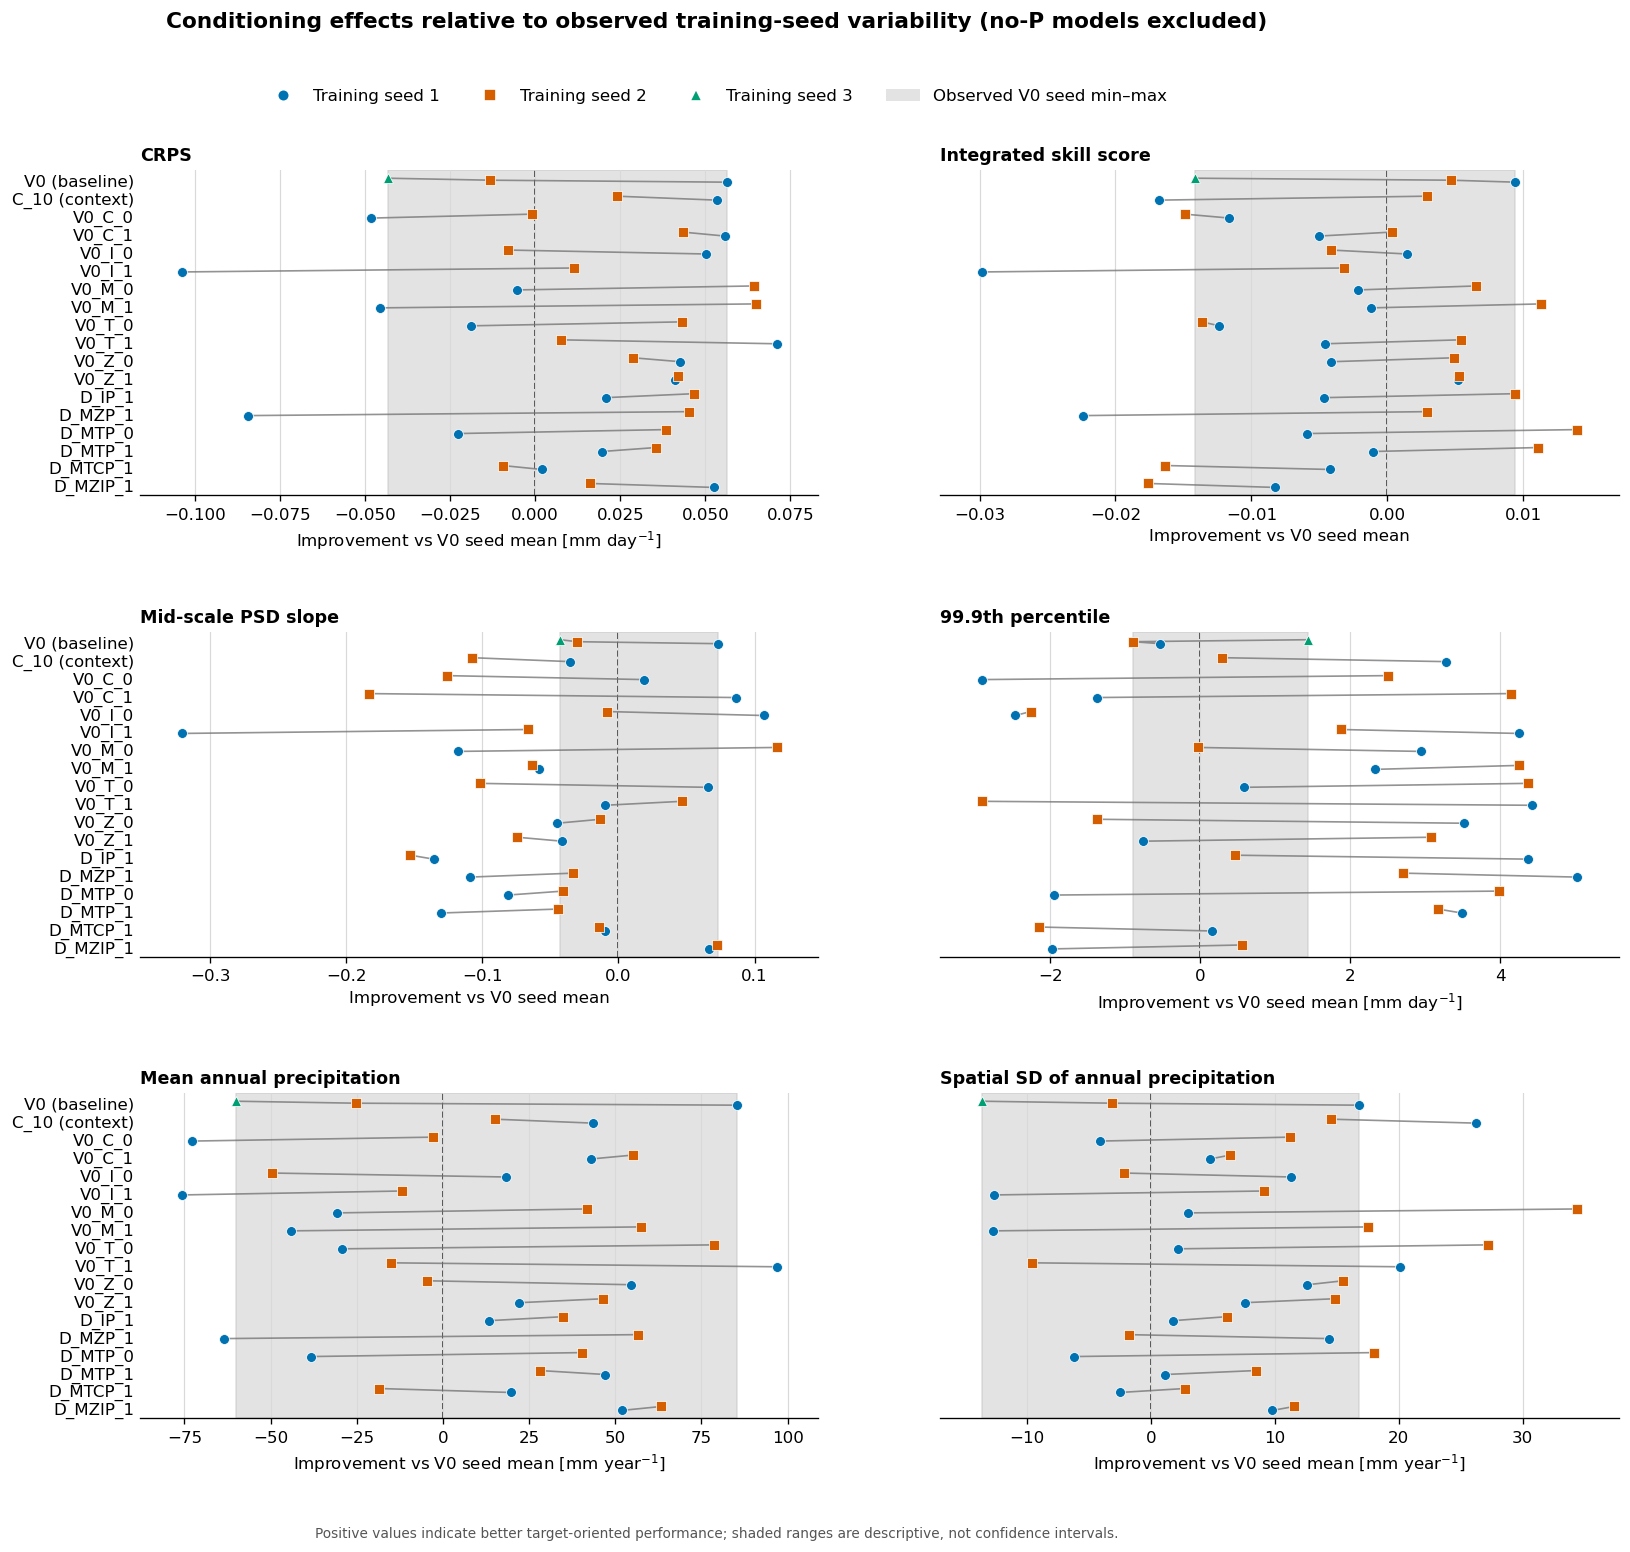

Saved 02_improvements_with_no_p.png and 02_improvements_with_no_p.pdf


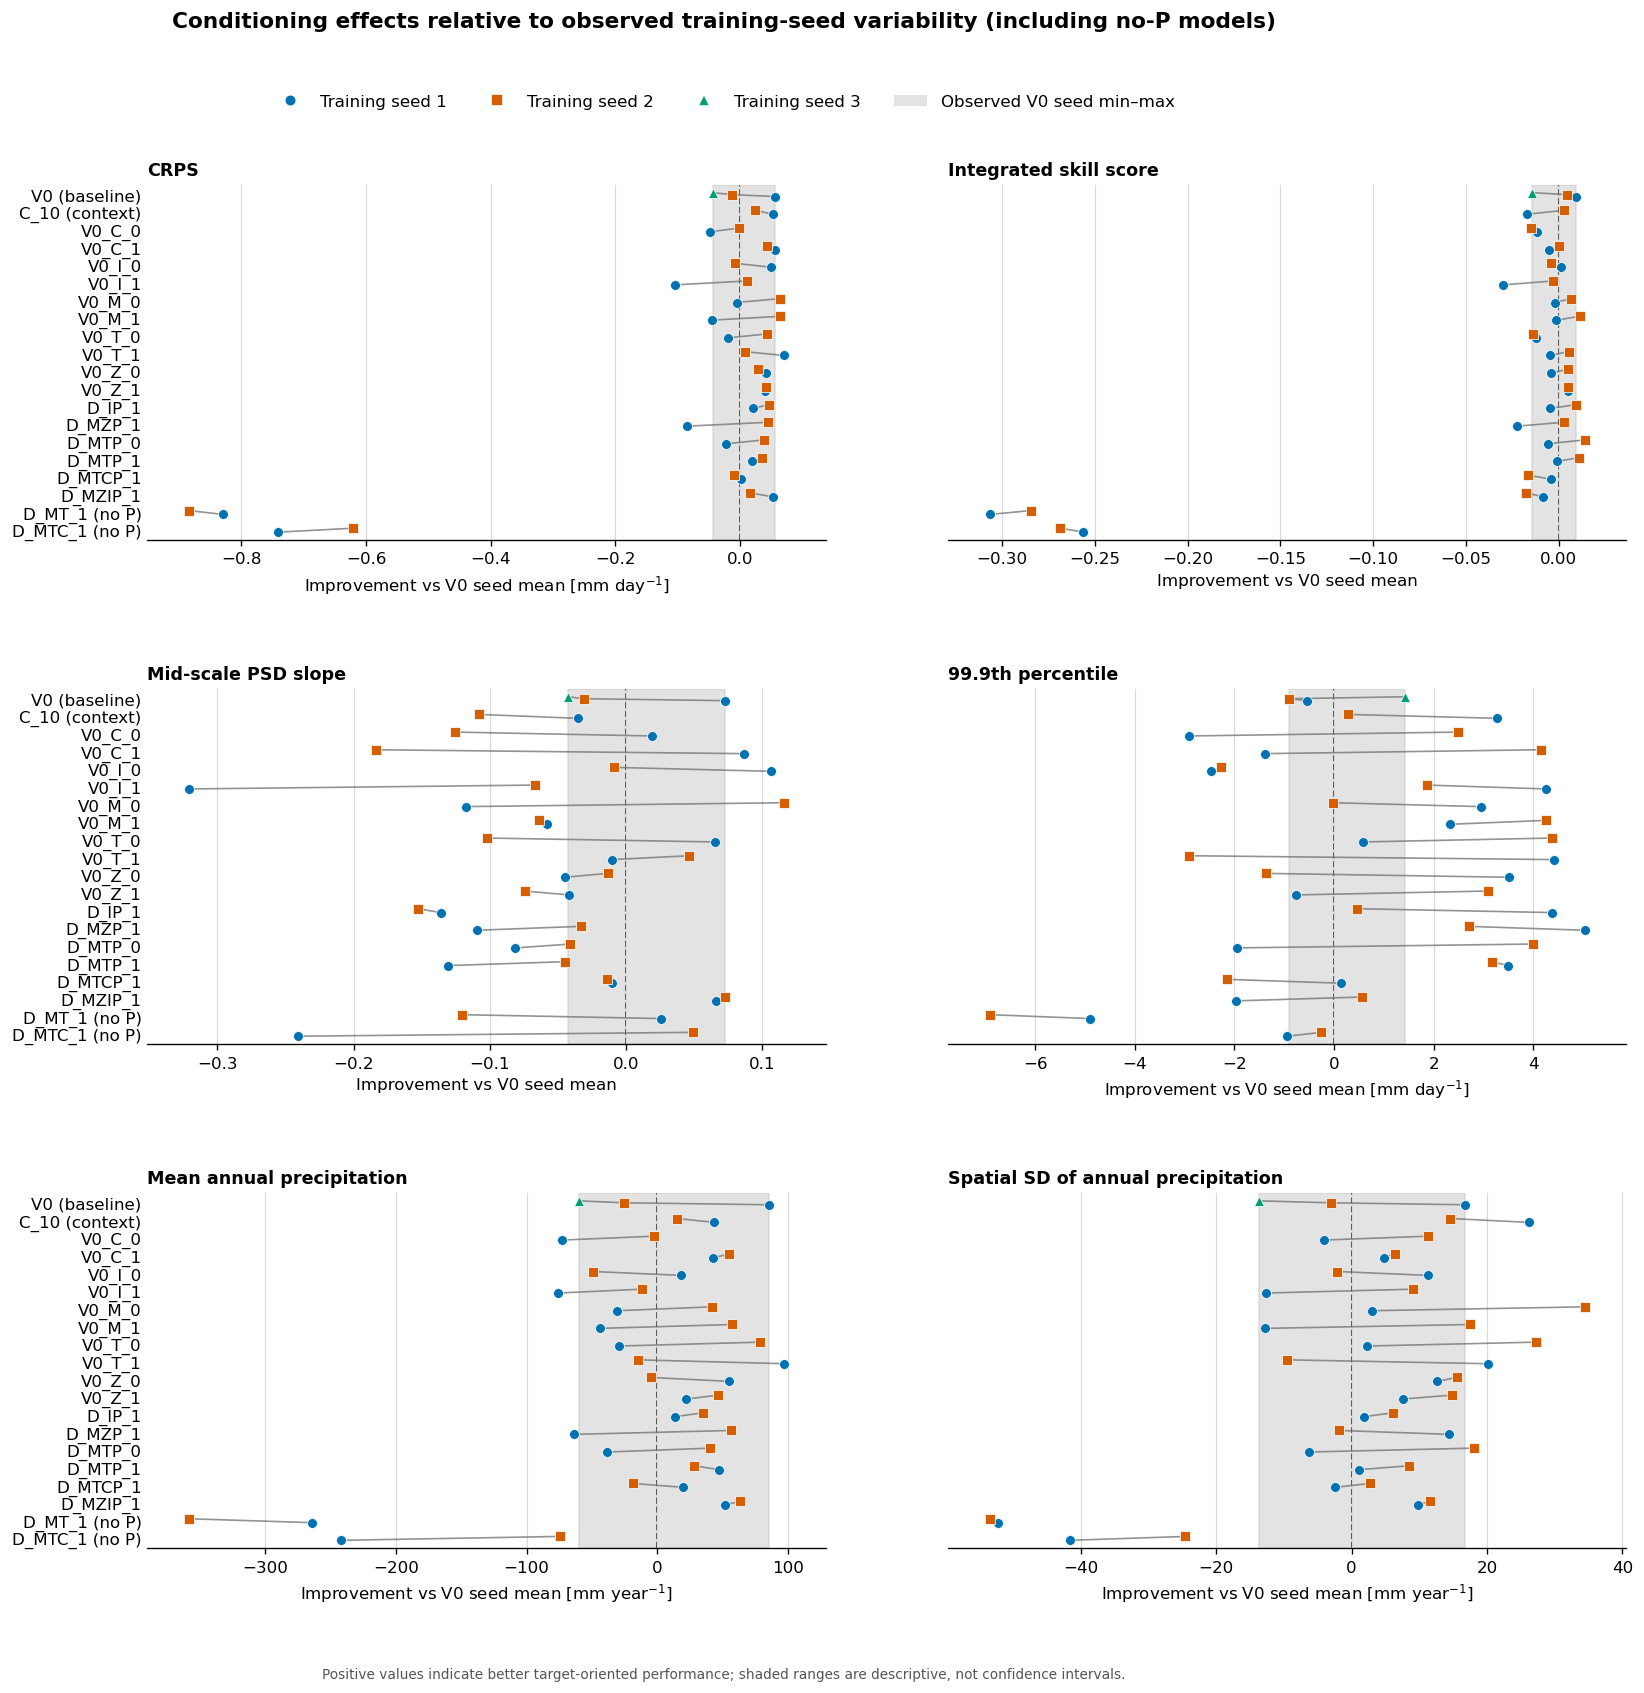

In [9]:
focused_improvement_figure, _ = ai4cc.plot_figure2(
    improvements,
    representative_metrics,
    configuration_order=configuration_order,
    include_no_p=False,
    figsize=(15.5, 13.0),
)
save_figure(focused_improvement_figure, '01_improvements_without_no_p')
plt.show()

full_improvement_figure, _ = ai4cc.plot_figure2(
    improvements,
    representative_metrics,
    configuration_order=configuration_order,
    include_no_p=True,
    figsize=(15.5, 14.2),
)
save_figure(full_improvement_figure, '02_improvements_with_no_p')
plt.show()

**What this plot can show:** whether a conditioning effect is large compared with the observed V0 seed range, and whether seed 1 and seed 2 tell the same story.

**What it cannot show:** the full sampling distribution across training seeds. With two seeds for most configurations, an apparently narrow pair may be accidental.

**Why the next step?** A target-oriented difference can hide the absolute reference value. We therefore inspect the same representative metrics in their original units.

## 5. Absolute values and evaluation targets

This view is a guard against overinterpreting a relative improvement. It shows whether all models are already close to the target, whether a numerically large improvement remains physically poor, and whether different seeds straddle the reference.

Saved 03_absolute_targets_without_no_p.png and 03_absolute_targets_without_no_p.pdf


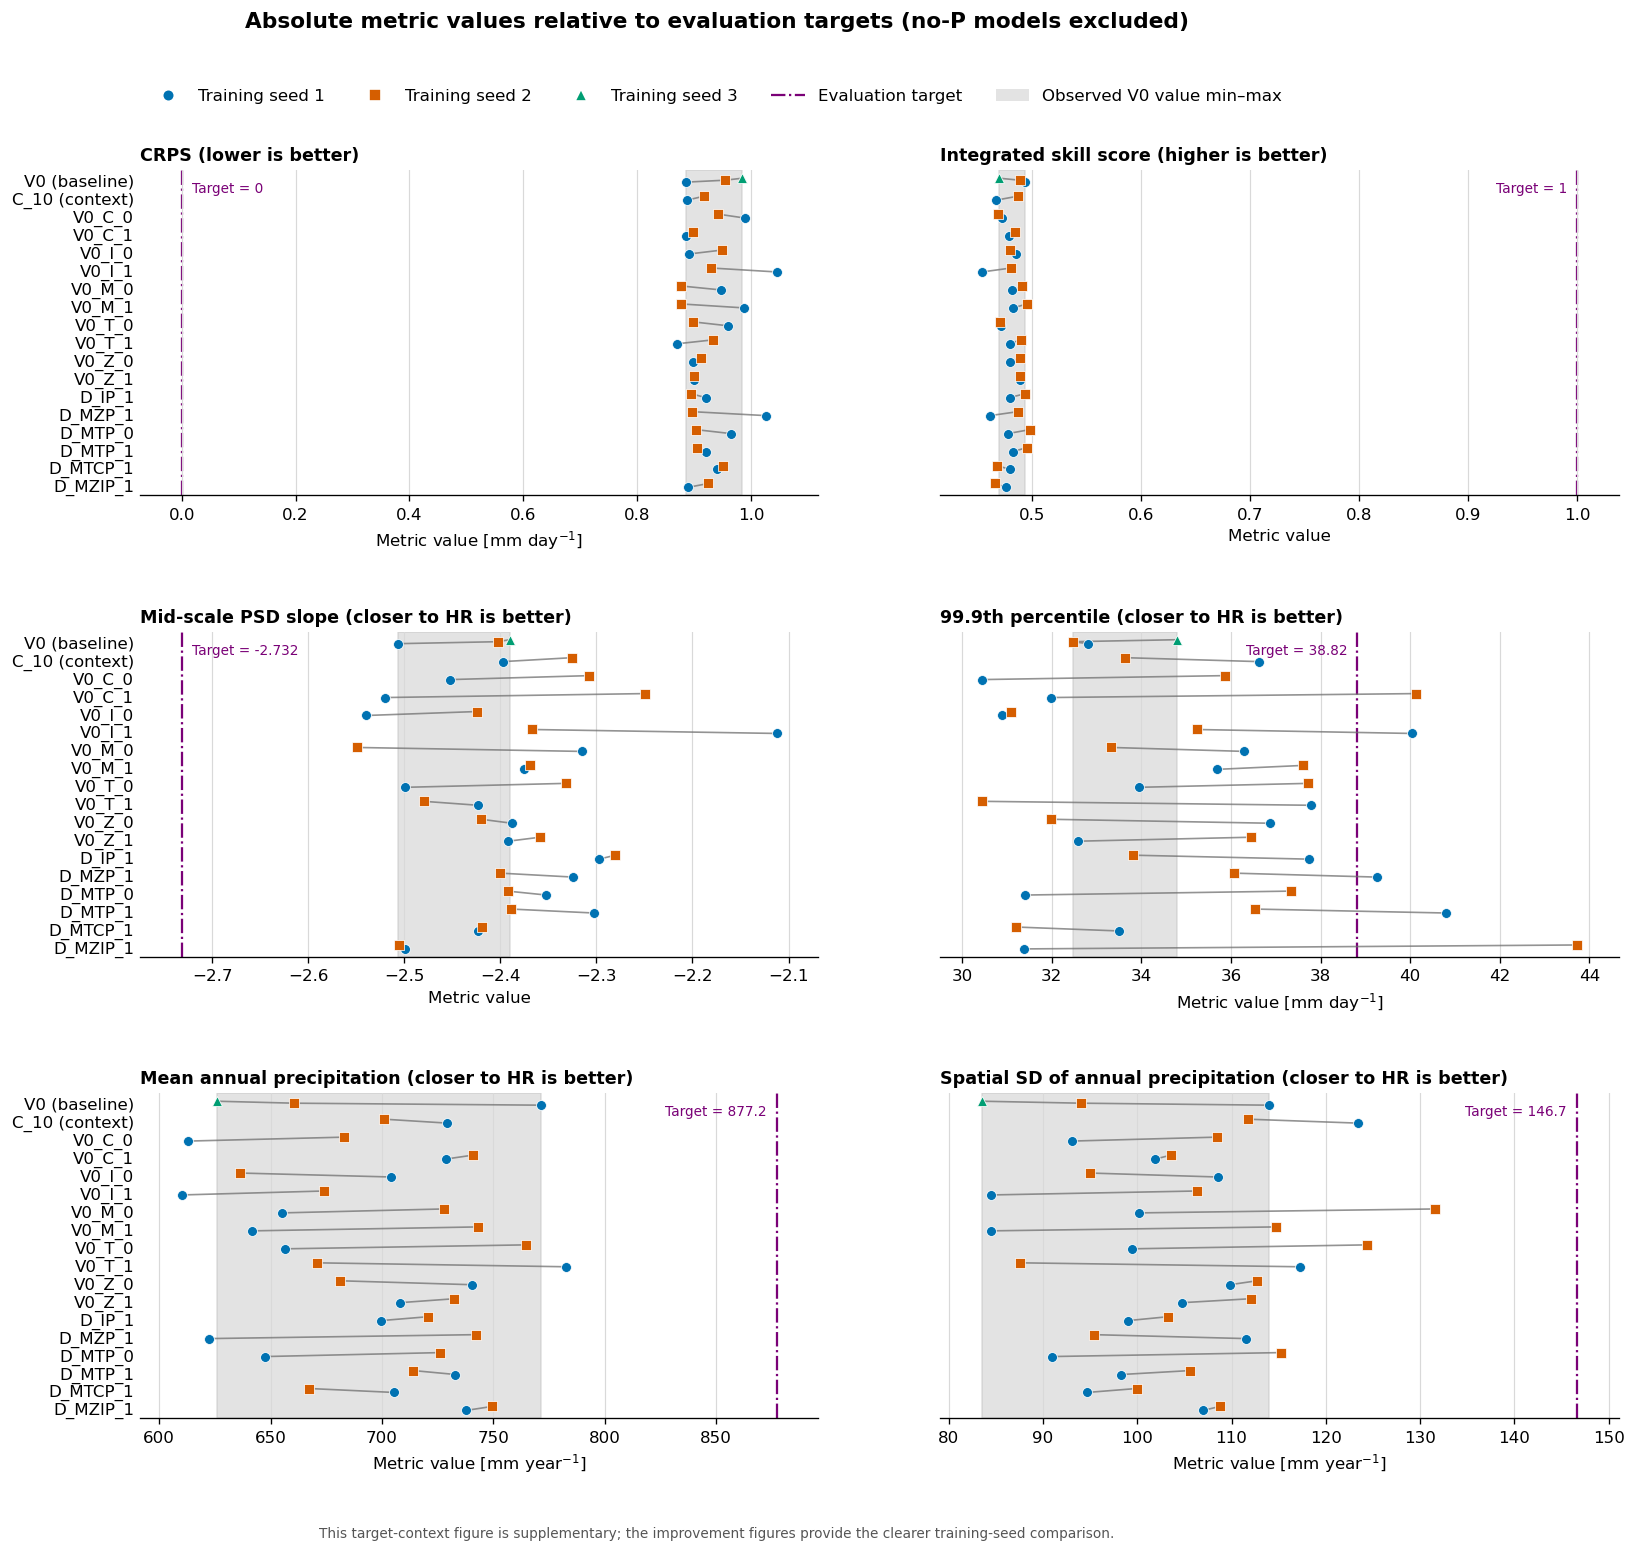

In [10]:
absolute_figure, _ = ai4cc.plot_absolute_targets(
    improvements,
    representative_metrics,
    configuration_order=configuration_order,
    include_no_p=False,
    figsize=(15.5, 13.0),
)
save_figure(absolute_figure, '03_absolute_targets_without_no_p')
plt.show()

## 6. Seed sensitivity across the core metric registry

For each configuration and metric, seed sensitivity is

$$S_{c,m}=\frac{|x_{c,m,1}-x_{c,m,2}|}{\max(x_{V0,m})-\min(x_{V0,m})}.$$

A value of 1 means that the seed-1/seed-2 gap equals the full observed V0 seed range for that metric. Values below 1 are less seed-sensitive than that descriptive reference. The configuration summary is the median across metrics, making it less dominated by isolated extreme gaps.

This normalization is useful for comparing metrics with different units, but it can become sensitive when the observed V0 range is very small. The detailed table should therefore remain available alongside the aggregate score.

In [11]:
core_sensitivity = ai4cc.compute_seed_sensitivity(
    raw,
    ai4cc.CORE_STABILITY_METRICS,
    configuration_order=configuration_order,
)
core_summary = ai4cc.summarize_seed_sensitivity(core_sensitivity)

display(core_summary.sort_values('median_normalized_gap').reset_index(drop=True))

,configuration,median_normalized_gap,mean_normalized_gap,q25_normalized_gap,q75_normalized_gap,maximum_normalized_gap,n_metrics,fraction_metrics_above_v0_range
0,V0_Z_1,0.282,0.492,0.161,0.789,1.652,21,0.143
1,D_MTCP_1,0.361,0.522,0.172,0.712,1.666,21,0.190
2,V0_C_1,0.365,1.088,0.084,1.247,6.067,21,0.333
3,D_MZIP_1,0.382,1.218,0.125,1.634,6.721,21,0.381
4,D_IP_1,0.383,0.626,0.147,0.688,2.301,21,0.190
5,V0_Z_0,0.408,103.484,0.274,0.956,2158.036,21,0.238
6,D_MTP_1,0.455,0.601,0.240,0.823,1.833,21,0.190
7,C_10,0.490,0.565,0.279,0.837,1.285,21,0.238
8,D_MTP_0,0.555,0.737,0.345,0.845,3.152,21,0.190
9,V0_I_0,0.580,0.848,0.391,0.932,5.698,21,0.190


Saved 04_core_seed_sensitivity_without_no_p.png and 04_core_seed_sensitivity_without_no_p.pdf


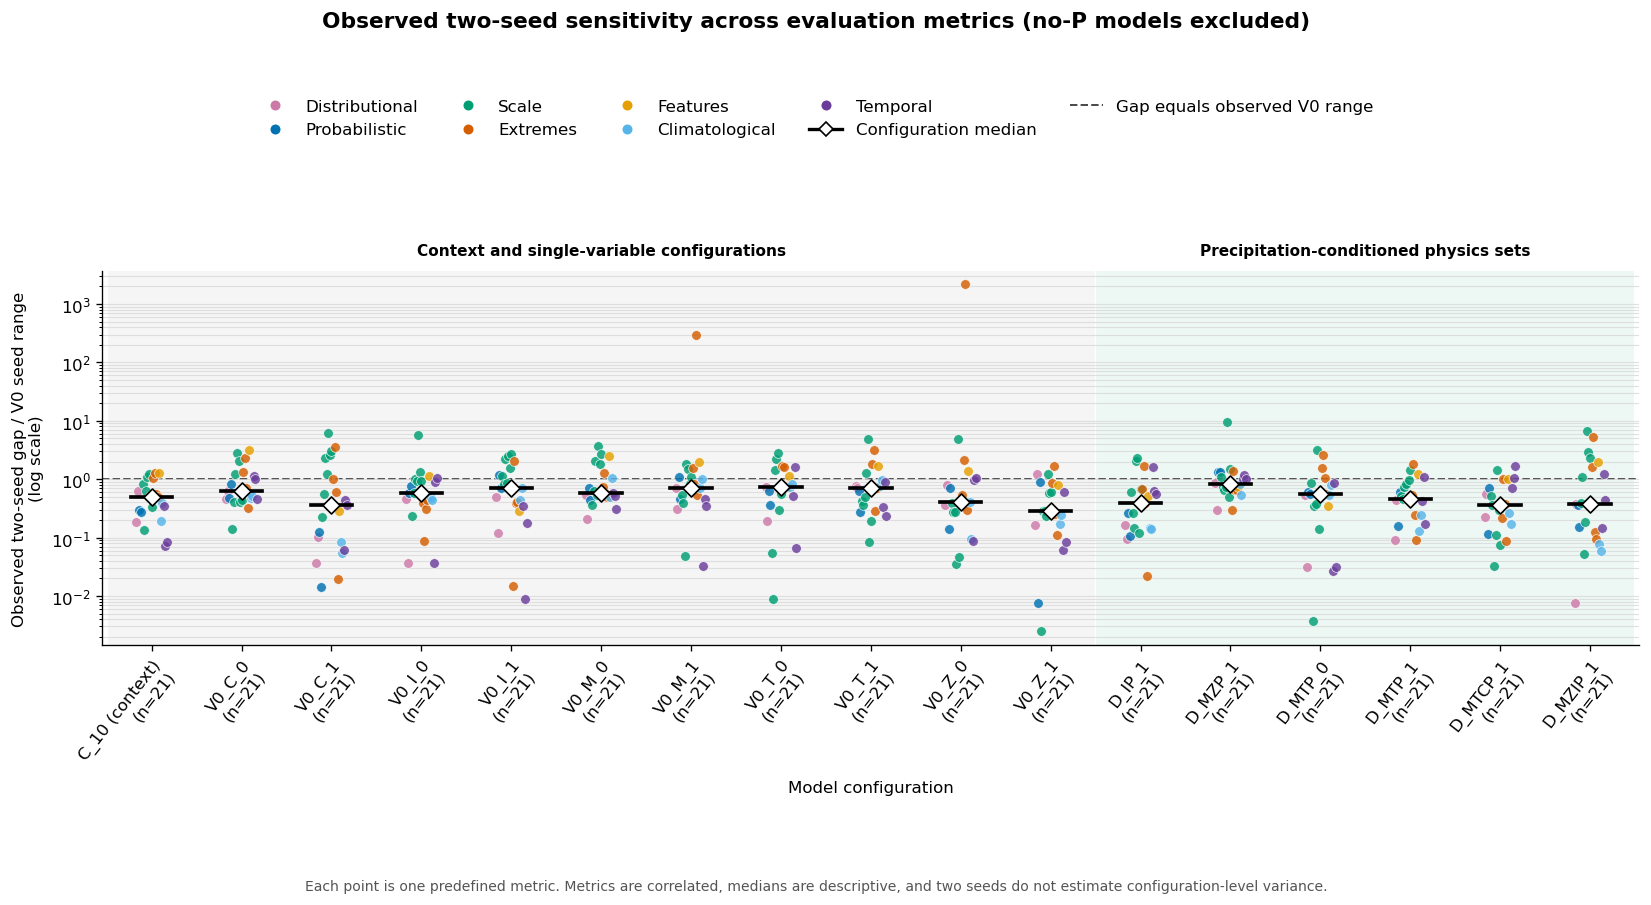

In [12]:
core_sensitivity_figure, _ = ai4cc.plot_seed_sensitivity(
    core_sensitivity,
    configuration_order=configuration_order,
    include_no_p=False,
    figsize=(14.0, 7.6),
)
save_figure(core_sensitivity_figure, '04_core_seed_sensitivity_without_no_p')
plt.show()

### Why retain a linear scale?

The main stability plots use a linear axis because zero and one have direct meanings: zero is no observed seed gap, and one equals the V0 seed range. A logarithmic axis cannot display zero and visually enlarges small differences while compressing the configurations with genuinely large seed gaps.

Instead of using a log scale to accommodate the no-P outliers, the notebook keeps a focused plot without no-P models and a companion full analysis. A log-scale sensitivity plot can still be useful as a supplementary diagnostic, but it should not replace the linear main figure.

## 7. Does the stability ranking depend on metric choice?

A low median over many metrics is not automatically robust. Three checks are used:

1. **Core metric median:** the original 21-metric stability registry.
2. **Expanded metric median:** 31 metrics after adding distinct calibration, spatial, extreme, feature, and spell diagnostics.
3. **Equal-pillar median:** first take the median within each of seven evaluation pillars, then the median across pillars. This prevents the pillar with the most listed metrics from receiving the greatest implicit weight.

A leave-one-pillar-out audit then asks how much each configuration's rank changes when an entire evaluation pillar is omitted.

In [13]:
expanded_sensitivity = ai4cc.compute_seed_sensitivity(
    raw,
    ai4cc.EXPANDED_STABILITY_METRICS,
    configuration_order=configuration_order,
)

core_pillar_detail, core_pillar_balanced = (
    ai4cc.summarize_pillar_balanced_sensitivity(core_sensitivity)
)
expanded_pillar_detail, expanded_pillar_balanced = (
    ai4cc.summarize_pillar_balanced_sensitivity(expanded_sensitivity)
)
leave_one_out = ai4cc.leave_one_pillar_out_sensitivity(expanded_pillar_detail)

robustness = ai4cc.build_stability_robustness_summary(
    core_sensitivity,
    expanded_sensitivity,
    expanded_pillar_balanced,
    leave_one_out,
)
group_summary = ai4cc.summarize_stability_by_group(robustness)

In [14]:
display(group_summary)

rank_columns = [
    'core_metric_rank',
    'expanded_metric_rank',
    'pillar_balanced_rank',
]
display(robustness[rank_columns].corr(method='spearman').rename_axis('ranking'))

,configuration_group,n_configurations,core_group_median_gap,expanded_group_median_gap,pillar_balanced_group_median_gap
0,context/single-variable,11,0.588,0.536,0.514
1,precipitation-conditioned physics set,6,0.419,0.448,0.429
2,no-P,2,1.028,1.052,0.802


,core_metric_rank,expanded_metric_rank,pillar_balanced_rank
ranking,,,
core_metric_rank,1.000,0.975,0.823
expanded_metric_rank,0.975,1.000,0.835
pillar_balanced_rank,0.823,0.835,1.000


Saved 05_stability_ranking_robustness.png and 05_stability_ranking_robustness.pdf


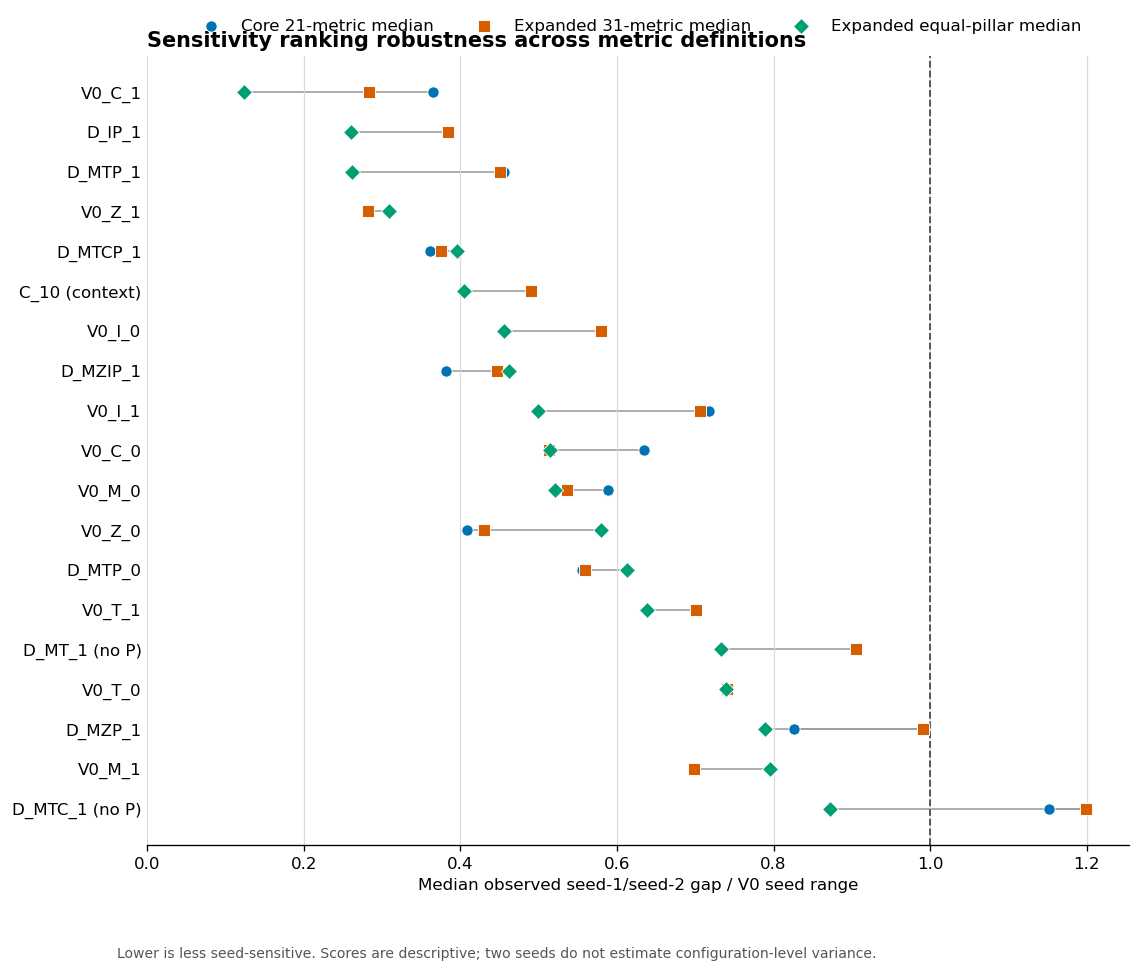

In [15]:
robustness_figure, _ = ai4cc.plot_stability_robustness(
    robustness,
    include_no_p=True,
    figsize=(11.2, 9.0),
)
save_figure(robustness_figure, '05_stability_ranking_robustness')
plt.show()

**Reading this diagnostic:** configurations whose three markers remain close are comparatively insensitive to the precise metric aggregation. Large horizontal separations indicate that the apparent stability depends on which diagnostics or weights are used.

Group medians can reveal a broad tendency—for example, whether precipitation-conditioned physics sets are less seed-sensitive on average—but they should not be treated as inferential tests. The configurations are neither independent experimental replicates nor a random sample of possible architectures.

In [16]:
leave_one_out_instability = (
    robustness[[
        'configuration',
        'best_leave_one_pillar_out_rank',
        'worst_leave_one_pillar_out_rank',
        'leave_one_pillar_out_rank_range',
    ]]
    .sort_values('leave_one_pillar_out_rank_range', ascending=False)
    .reset_index(drop=True)
)
display(leave_one_out_instability)

# Detailed scores reveal which omitted pillar caused each rank change.
display(leave_one_out.head(20))

,configuration,best_leave_one_pillar_out_rank,worst_leave_one_pillar_out_rank,leave_one_pillar_out_rank_range
0,D_MZIP_1,5,12,7
1,V0_Z_1,2,8,6
2,D_MTP_1,1,6,5
3,C_10,3,8,5
4,D_MT_1,14,19,5
5,V0_C_0,7,11,4
6,D_MTCP_1,2,6,4
7,V0_I_1,7,11,4
8,V0_M_0,8,12,4
9,V0_Z_0,10,14,4


,configuration,leave_one_out_median_gap,leave_one_out_rank,omitted_pillar
0,V0_C_1,0.263,1,Climatological
1,D_IP_1,0.391,2,Climatological
2,D_MTCP_1,0.419,3,Climatological
3,D_MTP_1,0.430,4,Climatological
4,V0_Z_1,0.450,5,Climatological
5,C_10,0.464,6,Climatological
6,V0_I_1,0.490,7,Climatological
7,V0_I_0,0.501,8,Climatological
8,V0_M_0,0.520,9,Climatological
9,V0_C_0,0.532,10,Climatological


**Why the next step?** Stability alone is not sufficient. A configuration can be stably poor, and a configuration with mixed seeds may look acceptable after averaging. The final analysis therefore combines direction of performance with agreement between seeds.

## 8. Target-aware agreement across 28 interpretable metrics

The attribution audit uses metrics with a defensible target or high-resolution reference. GEN–LR correlations remain useful seed-sensitivity diagnostics, but are excluded here because neither increasing nor decreasing that correlation is unambiguously better for a stochastic downscaler.

For each configuration–metric pair:

- **both favourable:** both seeds lie beyond the favourable side of the observed V0 envelope;
- **both inside V0 range:** both seeds are indistinguishable from that descriptive envelope;
- **both unfavourable:** both lie beyond its unfavourable side;
- **mixed:** the two seeds receive different classifications.

The categories are descriptive attribution labels—not significance tests.

In [17]:
attribution_improvements = ai4cc.compute_improvements(
    raw,
    ai4cc.ROBUSTNESS_ATTRIBUTION_METRICS,
)
metric_to_pillar = {
    metric: pillar
    for metric, _, pillar in ai4cc.EXPANDED_STABILITY_METRICS
    if metric in ai4cc.ROBUSTNESS_ATTRIBUTION_METRICS
}
attribution_seed_detail, attribution_summary = (
    ai4cc.summarize_attribution_classes(
        attribution_improvements,
        metric_to_pillar,
    )
)

display(
    attribution_summary.sort_values(
        ['fraction_both_unfavourable', 'fraction_mixed'],
        ascending=[True, True],
    ).reset_index(drop=True)
)

pair_status,configuration,both_favourable,both_inside_v0_range,both_unfavourable,mixed,n_metrics,fraction_both_favourable,fraction_both_inside_v0_range,fraction_both_unfavourable,fraction_mixed
0,V0_T_0,2,15,0,11,28,0.071,0.536,0.000,0.393
1,D_MTP_0,2,11,0,15,28,0.071,0.393,0.000,0.536
2,D_MTCP_1,1,16,1,10,28,0.036,0.571,0.036,0.357
3,C_10,3,13,1,11,28,0.107,0.464,0.036,0.393
4,D_MZIP_1,2,14,1,11,28,0.071,0.500,0.036,0.393
5,D_MZP_1,3,5,1,19,28,0.107,0.179,0.036,0.679
6,V0_T_1,1,7,1,19,28,0.036,0.250,0.036,0.679
7,V0_C_1,4,16,2,6,28,0.143,0.571,0.071,0.214
8,D_MTP_1,3,14,2,9,28,0.107,0.500,0.071,0.321
9,V0_Z_1,1,15,2,10,28,0.036,0.536,0.071,0.357


Saved 06_target_aware_seed_agreement.png and 06_target_aware_seed_agreement.pdf


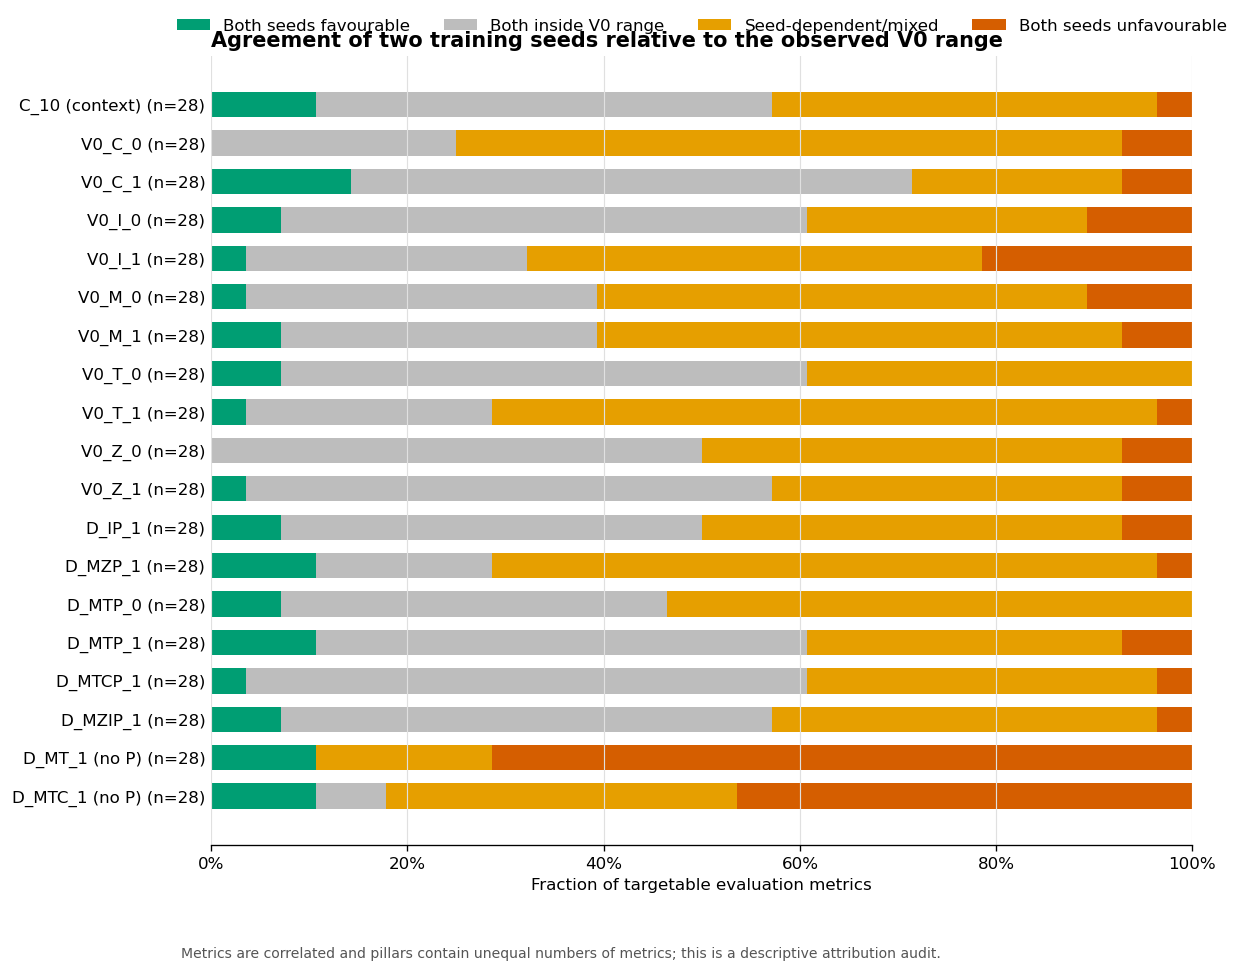

In [18]:
attribution_figure, _ = ai4cc.plot_attribution_composition(
    attribution_summary,
    configuration_order,
    figsize=(11.2, 9.0),
)
save_figure(attribution_figure, '06_target_aware_seed_agreement')
plt.show()

## 9. Guardrails for interpretation

- Two seeds demonstrate that model–seed selection can alter conclusions, but they cannot establish that one configuration has intrinsically lower variance.
- The V0 min–max envelope is an observed reference range, not an uncertainty interval.
- Metrics within and across pillars are correlated. Neither 31 metrics nor 28 targetable metrics represent 31 or 28 independent pieces of evidence.
- Equal-pillar weighting is a sensitivity analysis, not a uniquely correct weighting scheme.
- A configuration should not be selected solely because it has the smallest seed gap: stability must be considered jointly with physical adequacy and target-oriented performance.
- Seasonal and monthly precipitation behaviour remains a meaningful gap in the summary-level analysis and would require new aggregation from the raw evaluation outputs.

A defensible manuscript claim is therefore about **selection uncertainty**: the observed conditioning effect is often comparable to training-seed variability, so choosing the best individual model–seed realization can overstate evidence for a configuration.

## 10. Export the intermediate evidence

Saving the intermediate tables makes the figure traceable. These files are particularly useful when writing the results section because every aggregate score can be traced back to a configuration, metric, pillar, and seed.

In [ ]:
tables_to_export = {
    'configuration_inventory': inventory,
    'metric_coverage_audit': coverage,
    'representative_improvements': improvements,
    'core_seed_sensitivity': core_sensitivity,
    'core_seed_sensitivity_summary': core_summary,
    'expanded_seed_sensitivity': expanded_sensitivity,
    'expanded_pillar_detail': expanded_pillar_detail,
    'expanded_pillar_balanced_summary': expanded_pillar_balanced,
    'leave_one_pillar_out': leave_one_out,
    'stability_robustness_summary': robustness,
    'stability_group_summary': group_summary,
    'attribution_seed_classifications': attribution_seed_detail,
    'attribution_pair_summary': attribution_summary,
}

for name, table in tables_to_export.items():
    path = OUTPUT_DIR / f'{name}.csv'
    table.to_csv(path, index=False)

print(f'Exported {len(tables_to_export)} tables to {OUTPUT_DIR}')

## Suggested manuscript roles

- The six-metric improvement figure without no-P models is the clearest candidate for the main text because it directly compares conditioning effects with observed seed variability.
- The absolute-target view is a useful companion or supplement that prevents a relative score from being mistaken for absolute quality.
- The ranking-robustness and attribution-composition figures support the methodological claim that model selection should consider stability and agreement, not only the best model–seed result.
- The full no-P plots, detailed metric tables, and leave-one-pillar-out audit fit naturally in supplementary material.

The notebook intentionally ends with diagnostics rather than an automatic winner. Model selection remains a scientific judgement combining performance, seed stability, physical plausibility, and the manuscript's intended claim.